## Student t-Paylanması

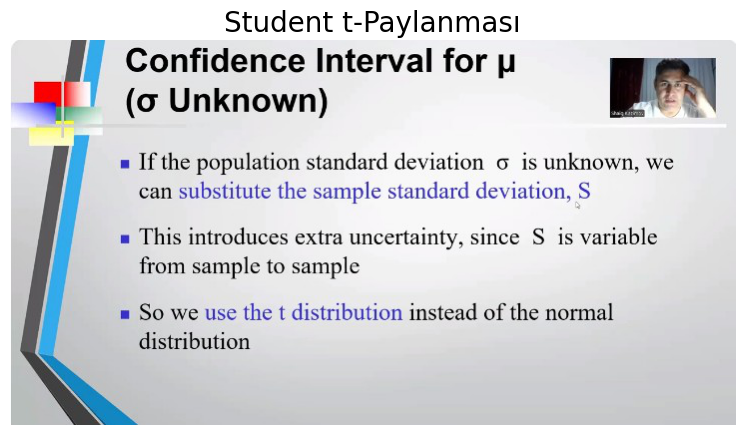

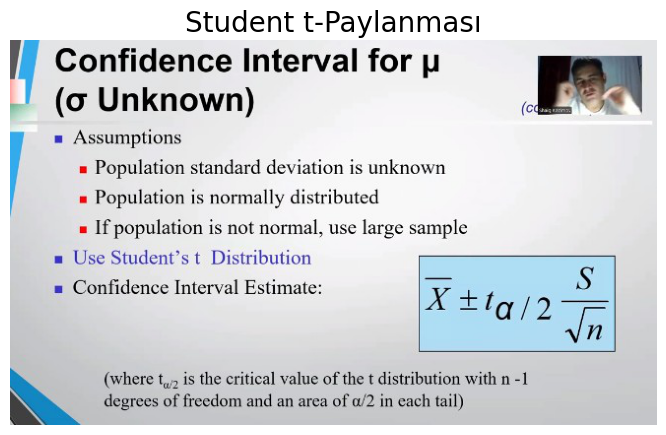

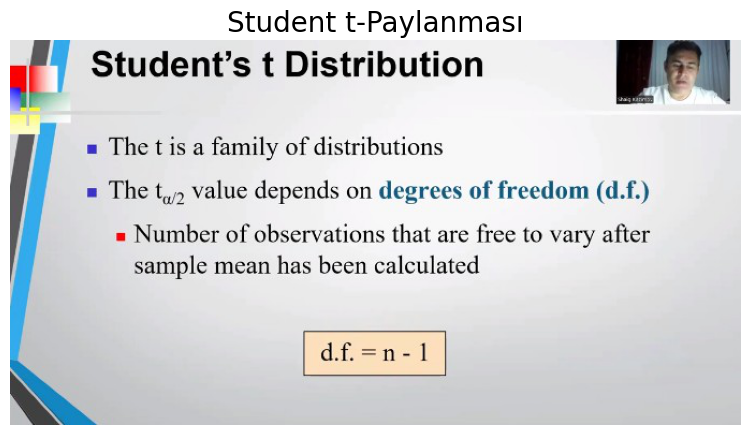

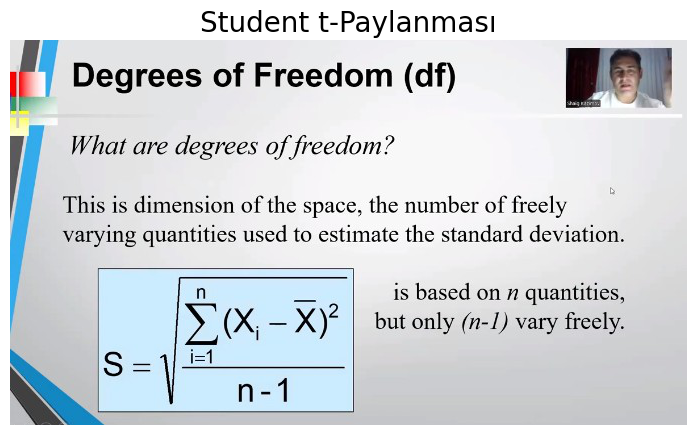

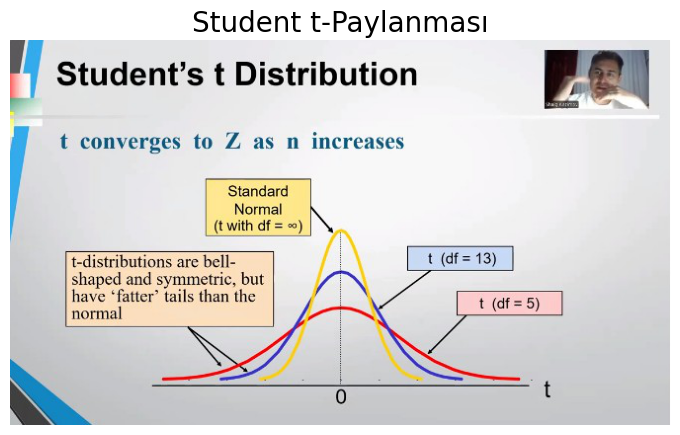

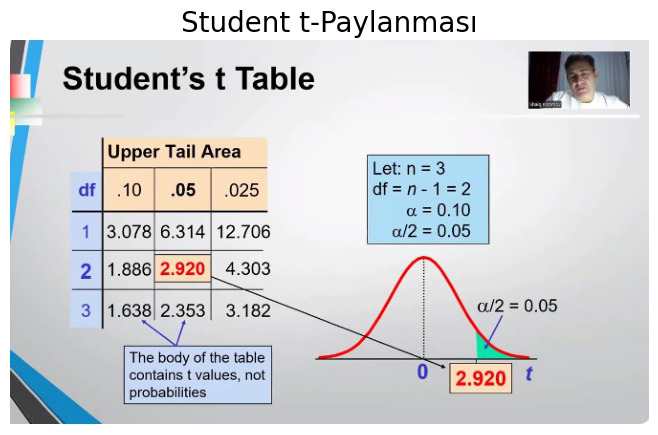

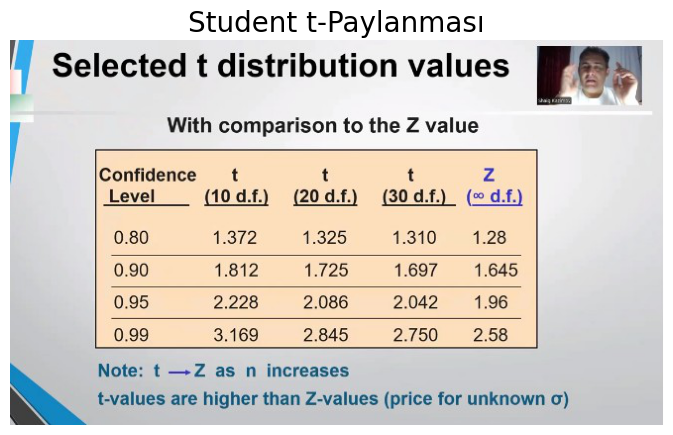

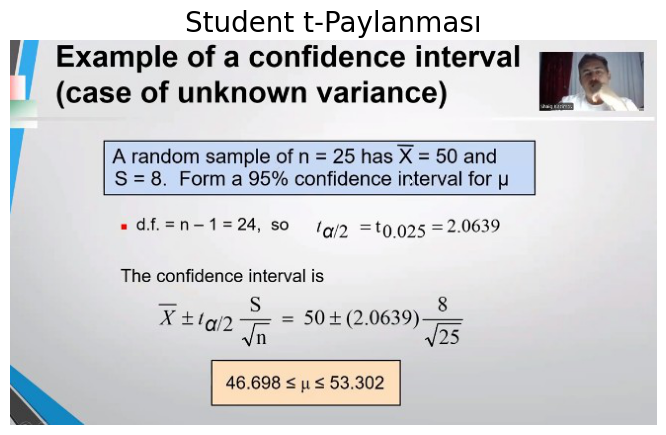

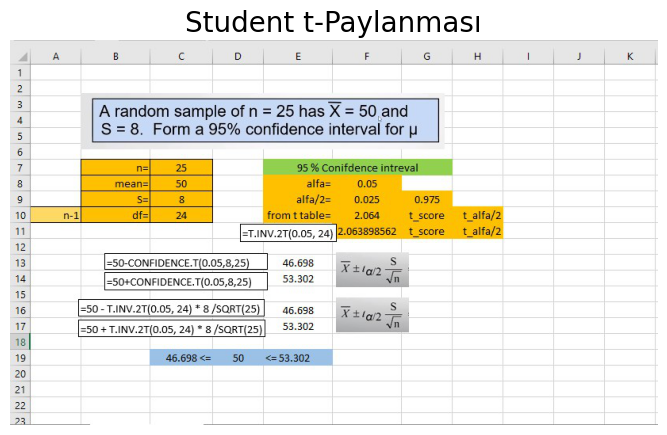

In [1]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Excel\Handex Excel\Statistics\Season_2\Telim_10\Pictures\Distribution_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 10):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for image in image_list:
    plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü
    plt.title('Student t-Paylanması', size=20)
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

## Confidence interval

- **Python ilə Ortalaması 50, Standart Sapması 8 və Nümunə Sayı 25 olan Məlumat Üçün 95% Etibarlılıq (Güvən) İntervalının Hesablanması.**



In [10]:
import scipy.stats as stats
import math

# Verilənlər
n = 25
mean = 50
s = 8

# Azadlıq dərəcəsi
df = n - 1

# Kritik t dəyəri (95% üçün)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df)

# Standard Error
SE = s / math.sqrt(n)

# Etibarlılıq intervallı
lower = mean - t_crit * SE
upper = mean + t_crit * SE

print(f"95% confidence interval: ({lower:.2f}, {upper:.2f})")

95% confidence interval: (46.70, 53.30)


## Student t-Paylanması



### ✅ **1. Student t-Paylanmasının Tərifi**

> **Tərif:** Student t-paylanması — **kontinu (kəsilməz)** və **simmetrik** ehtimal paylanmasıdır, **orta ətrafında zəngvari forma** alır. Ancaq **uc (tail) hissələri normal paylanmadan daha qalındır**, bu da **kiçik nümunələrdə daha real nəticələr** verir.

> **Tərif:** Student t-paylanması, xüsusilə **nümunə həcmi kiçik olduqda** və **əsl dispersiya (σ²) məlum olmadıqda** istifadə edilir. Təsadüfi dəyişənin orta ətrafında necə yayıldığını göstərir, amma **standart sapma əvəzinə nümunə standart sapmasından (s)** istifadə olunur.

---

### ✅ Parametrlər

* `ν` (və ya `df`) — **Azadlıq dərəcəsi** (degrees of freedom)
* `x` — Ehtimalı hesablanacaq konkret dəyər

> 💡 Əgər nümunə ölçüsü `n`-dirsə, adətən `ν = n - 1`

---

**t-paylanması** adətən belə halları modelləşdirir:

* Nümunə **kiçikdir (n < 30)** və əhalinin standart sapması **naməlumdur**.
* Paylanma **simmetrik və zəngvaridir**, amma **uc ehtimallar daha yüksəkdir**.
* Azadlıq dərəcəsi artdıqca **t-paylanması normal paylanmaya yaxınlaşır**.
* Yalnız **bir parametr — azadlıq dərəcəsi (ν)** ilə idarə olunur.

Təsadüfi dəyişən aşağıdakı kimi göstərilir:

$$
T \sim t(\nu)
$$

---

### ✅ 2. Student t-Paylanmanın Düsturu (PDF)

**Ehtimal sıxlıq funksiyası (PDF)** aşağıdakı kimidir:

$$
f(t) = \frac{\Gamma\left(\frac{\nu + 1}{2} \right)}{\sqrt{\nu \pi} \cdot \Gamma\left(\frac{\nu}{2} \right)} \cdot \left(1 + \frac{t^2}{\nu} \right)^{-\frac{\nu + 1}{2}}
$$

---

### 🎯 Burada hər simvol nəyi bildirir?

* \$\nu\$ — Azadlıq dərəcəsi
* \$t\$ — Təsadüfi dəyişənin dəyəri
* \$\Gamma\$ — Gamma funksiyası (fakultetin davamı)
* \$\pi\$ — Təqribən 3.1416

---

### ✅ Məsələn:

**Sual:** Nümunə ölçüsü 10-dur (\$\nu = 9\$). T = 1.83 üçün ehtimal sıxlığını tap.

> Bu tip suallarda əllə hesablamaq çətindir — adətən **Python**, **Excel** və ya **t-cədvəllər** istifadə olunur.

---

### ✅ 3. Riyazi Gözləmə (Expected Value)

$$
\mathbb{E}[T] = 0 \quad \text{(əgər } \nu > 1)
$$

#### 💡 Qeyd:

* Əgər \$\nu \leq 1\$, gözlənilən dəyər **mövcud deyil**.
* \$\nu > 1\$ olduqda ortalama **0**-dır.

---

### ✅ 4. Dispersiya (Varyans)

$$
Var(T) = \frac{\nu}{\nu - 2}, \quad \text{(əgər } \nu > 2)
$$

#### 💡 Qeyd:

* \$\nu \leq 2\$ olduqda dispersiya **mövcud deyil**
* \$\nu > 30\$ olduqda artıq normal paylanmaya çox yaxınlaşır

---

### ✅ 5. Cumulative Distribution Function (CDF)

Student t-paylanmasında müəyyən aralıqdakı ehtimal aşağıdakı kimi tapılır:

$$
P(a < T < b) = F(b) - F(a)
$$

Burada:

* \$F(t)\$ — **t-paylanma üzrə CDF**
* CDF inteqral formasında hesablanır:

$$
F(t) = \int_{-\infty}^{t} f(u) \, du
$$

> 💡 Əllə hesablamaq olmur — **statistik proqramlar**, **t-cədvəlləri**, və ya `scipy.stats.t.cdf()` kimi funksiyalar istifadə olunur.

---

### 🧠 Əlavə izah — t-statistik nədir?

**t-score** — orta qiymətin əhali ortasından **nümunə standart sapması ilə** nə qədər uzaqda olduğunu göstərir:

$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$$

Burada:

* \$\bar{x}\$ — nümunə ortası
* \$\mu\_0\$ — müqayisə edilən nəzəri orta
* \$s\$ — nümunə standart sapması
* \$n\$ — nümunə ölçüsü

---

### ✅ 6. t-paylanmanın Normal Paylanma ilə fərqi

| Xüsusiyyət      | Normal Paylanma                               | Student t-Paylanması                     |
| --------------- | --------------------------------------------- | ---------------------------------------- |
| Parametrlər     | Orta (μ), Standart sapma (σ)                  | Azadlıq dərəcəsi (ν)                     |
| Ehtimal forması | Dəqiq və dar                                  | Daha geniş quyruqlu (heavy tails)        |
| İstifadə sahəsi | Əhali dispersiyası məlumdur                   | Əhali dispersiyası **naməlumdur**        |
| Nümunə ölçüsü   | Böyük nümunələr                               | Kiçik nümunələr üçün uyğundur            |
| Z-score         | $z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}}$ | $t = \frac{\bar{x} - \mu}{s / \sqrt{n}}$ |

---

## ✅ 7. Qısa Cədvəl — Yekun

| Xüsusiyyət    | Düstur                                                                                                                                             | Açıqlama                   |
| ------------- | -------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------- |
| Paylanma tipi | $$T \sim t(\nu)$$                                                                                                                                    | Student t-paylanması       |
| PDF           | $$f(t) = \frac{\Gamma(\frac{\nu + 1}{2})}{\sqrt{\nu \pi} \cdot \Gamma(\frac{\nu}{2})} \cdot \left(1 + \frac{t^2}{\nu} \right)^{-\frac{\nu + 1}{2}}$$ | Ehtimal sıxlığı funksiyası |
| Gözləmə       | $$\mathbb{E}[T] = 0 \quad (\nu > 1)$$                                                                                                                | Orta dəyər                 |
| Dispersiya    | $$Var(T) = \frac{\nu}{\nu - 2} \quad (\nu > 2)$$                                                                                                     | Dəyişkənlik ölçüsü         |
| t-score       | $$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$                                                                                                         | Standart normallaşdırma    |
| CDF           | $$P(a < T < b) = F(b) - F(a)$$                                                                                                                       | Aralıq ehtimalı            |





## ✅ **T-score tapıldıqdan sonra, Student t-Paylanmasının Sıxlıq funksiyası (PDF) və ya Paylayıcı funksiyası (CDF) ilə ehtimal necə hesablanır?**




### ✅ **Qısa və Konkret İzahlı Yazılış:**

* **T-score düsturu:**

$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$$

> Burada:
>
> * \$\bar{x}\$ – nümunə ortalaması
> * \$\mu\_0\$ – nəzəri (test olunan) orta
> * \$s\$ – nümunə standart sapması
> * \$n\$ – nümunə ölçüsü

📌 **Nümunə:**

Əgər:
\$\bar{x} = 74\$, \$\mu\_0 = 70\$, \$s = 8\$, \$n = 16\$

Onda:

$$
t = \frac{74 - 70}{8 / \sqrt{16}} = \frac{4}{2} = 2.0
$$

---

### ✅ **T-score verilibsə ehtimal necə tapılır?**

T cədvəli və ya aşağıdakı **CDF** funksiyası istifadə olunur:

$$
P(T \leq t) = F_\nu(t) = \int_{-\infty}^{t} f_\nu(u) \, du
$$

> Bu **Student t-paylanmasının paylayıcı funksiyasıdır** (CDF) və **azadlıq dərəcəsinə** (\$\nu = n - 1\$) bağlıdır.



### ✅ **T-score üçün ehtimal (CDF) düsturu:**

$$
P(T \leq t) = F(t; \nu) = \int_{-\infty}^{t} f(u; \nu) \, du
$$

> Burada:
>
> * \$t\$ — t-score dəyəri
> * \$\nu\$ — sərbəstlik dərəcəsi (degrees of freedom)
> * \$f(u; \nu)\$ — t-paylanmanın sıxlıq funksiyası (PDF)



📌 **Nümunə:**
Əgər \$t = 2.0\$ və \$\nu = 15\$ (yəni \$n = 16\$), onda:

$$
P(T \leq 2.0) \approx 0.970
$$

Yəni bu t-score altında təxminən **97% ehtimal** yerləşir.

---

### ✅ **Sıxlıq funksiyası (PDF) isə:**

$$
f(t) = \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\sqrt{\nu \pi} \cdot \Gamma\left(\frac{\nu}{2}\right)} \cdot \left(1 + \frac{t^2}{\nu} \right)^{-\frac{\nu + 1}{2}}
$$

> Bu **ehtimal sıxlığını** verir, **birbaşa ehtimal deyil.**

📌 **Nümunə:**
Əgər \$t = 1.5\$, \$\nu = 10\$:

$$
f(1.5) \approx 0.125 (təqribi)
$$

Bu dəyər **PDF dəyəridir**, yəni 1.5 ətrafındakı sıxlığı göstərir — **amma bu ehtimal deyil**.

---

### ✅ **Nəticə:**

* T-score → Student t-paylanma üzrə **CDF** ilə ehtimal → `T.DIST()` (Excel) və ya `scipy.stats.t.cdf()` (Python) ilə tapılır.
* CDF nəticəsi: \$P(T \leq t)\$ ehtimalıdır.

📌 **Nümunə:**

T-score \$t = 0\$ üçün ehtimal:

$$
P(T \leq 0) = F_\nu(0) = 0.5
$$

Yəni **t-paylanmada da simmetriya olduğundan**, ortadan aşağı və yuxarı düşmək ehtimalı **50%-dir.**

---

### **Qeyd**:

> **PDF** yalnız sıxlıq verir, **bir nöqtədə ehtimal sıfırdır**, müəyyən aralıqda ehtimal tapmaq üçün **CDF istifadə olunur.**

📌 **Nümunə fərqi:**

\$t = 1.5\$ üçün PDF təqribən \$f(1.5) = 0.125\$

Bu, **1.5 ətrafındakı sıxlıqdır**, **amma ehtimal deyil.**

---

### ✅ **Aralıq ehtimalı necə tapılır?**

$$
P(a < T < b) = F_\nu(b) - F_\nu(a)
$$

📌 **Nümunə:**

$$
P(-2 < T < 2) = F_{15}(2) - F_{15}(-2) \approx 0.970 - 0.030 = 0.940
$$

Yəni **t-score -2 ilə 2** arasında düşmə ehtimalı təxminən **94%-dir** (ν = 15 üçün).

---

### ✅ Yekun Fikir:

| Addım                   | Nə edilir                                  |
| ----------------------- | ------------------------------------------ |
| T-score hesablanır      | $$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$ |
| PDF ilə sıxlıq alınır   | $$f(t) = \ldots$$ (amma ehtimal deyil)       |
| CDF ilə ehtimal tapılır | $$P(T \leq t) = F_\nu(t)$$                   |
| Aralıq ehtimalı tapılır | $$P(a < T < b) = F_\nu(b) - F_\nu(a)$$       |




## Gamma funksiyası



### ✅ **Gamma (Γ) funksiyası nədir?**

**Gamma funksiyası** — **faktorialın genişləndirilməsi** kimi qəbul edilir və **qeyri-müsbət olmayan real və kompleks ədədlər** üçün təyin olunur.

Matematikada belə yazılır:

$$
\Gamma(n) = \int_0^{\infty} x^{n-1} e^{-x} dx
$$

Bu, **\$\Gamma\$ funksiyasının tərifidir**.

---

### ✅ Gamma funksiyasının faktorialla əlaqəsi:

Əgər \$n\$ — **müsbət tam ədəd**dirsə, o zaman:

$$
\Gamma(n) = (n - 1)!
$$

---

📌 **Nümunələr:**

| $$n$$           | $$\Gamma(n)$$                                                                   | $$(n-1)!$$ |
| --------------- | ------------------------------------------------------------------------------- | ---------- |
| 1               | $$\Gamma(1) = 0! = 1$$                                                          | $$1$$      |
| 2               | $$\Gamma(2) = 1! = 1$$                                                          | $$1$$      |
| 3               | $$\Gamma(3) = 2! = 2$$                                                          | $$2$$      |
| 4.5             | $$\Gamma(4.5)$$ — **faktorial kimi hesablana bilməz**, amma Gamma ilə mümkündür | —          |
| $$\frac{1}{2}$$ | $$\Gamma\left(\frac{1}{2}\right) = \sqrt{\pi}$$                                 | —          |

---

### ✅ Gamma funksiyası niyə t-paylanmada istifadə olunur?

t-paylanma PDF-dəki \$\Gamma\left(\cdot\right)\$ ifadəsi **normalizasiya əmsalı** verir. Yəni PDF funksiyası **bütün sahə üzrə 1 olsun deyə**, bu funksiyalar tələb olunur.

Normallaşdırma əmsalının formulu belədir:

$$
\frac{\Gamma\left( \frac{\nu + 1}{2} \right)}{\sqrt{\nu \pi} \cdot \Gamma\left( \frac{\nu}{2} \right)}
$$

Bu, əmin edir ki:

$$
\int_{-\infty}^{+\infty} f(t) \, dt = 1
$$

---

### ✅ Gamma funksiyasını hesablamaq (Python):

```python
from scipy.special import gamma

print(gamma(5))        # 4! = 24
print(gamma(0.5))      # √π ≈ 1.772
```

---

### 🔁 Nəticə:

* \$\Gamma(n)\$ — faktorialın genişləndirilməsidir
* Müsbət tam ədədlər üçün: \$\Gamma(n) = (n-1)!\$
* t-paylanmanın PDF formulunda **bütün ehtimal sahəsinin 1 olması üçün** istifadə olunur

